## RunModels_ForEachOfNClusters
This script:
- Reads the expanded dataframe (one row per image) with cluster assignments (output of script 5)
- For a chosen k, computes per-LSOA summary statistics:
    - Count and percentage of images in each cluster
    - Mean, max, and median embedding within each cluster
    - Overall mean, max, and median embedding (across all clusters)
- Joins to SES-WOA score data
- For each of the N clusters, trains an XGBoost model using only that cluster's embedding as features, with a simple 80/20 train-test split
- Compares model performance (R², RMSE, Spearman correlation) across clusters

### Dependencies
**Prerequisites:** Scripts 4 and 5 (needs best model and cluster-assigned pickle).

**Inputs:**
- `data/processed/one_row_per_image_cleaned_with_cluster_numbers.pkl` — from script 5
- `data/models/best_model.joblib` — from script 4 (cloned for per-cluster models)
- CBS SES-WOA target (via `amsterdam_data.get_ses_woa()`)
- `clustering_functions.py` — imports `global_k`, `embedding_statistic`, `agg_funcs`

**Outputs:**
- No saved files (results computed in memory); prints LaTeX table of per-cluster R², RMSE, Spearman

**Used by:** None (terminal analysis notebook)

In [1]:
import os
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from sklearn.base import clone
import matplotlib.pyplot as plt
import joblib

from model_evaluation import compute_metrics

In [2]:
from directory_filepaths import *
from clustering_functions import global_k, embedding_statistic, mean_embed, median_embed, max_embed, agg_funcs
from amsterdam_data import get_ses_woa
print(f"Number of clusters (defined in clustering_functions.py) = {global_k}")
print(f"Using '{embedding_statistic}' embedding aggregation (from clustering_functions.py)")
k = global_k

Number of clusters (defined in clustering_functions.py) = 5
Using 'median' embedding aggregation (from clustering_functions.py)


In [3]:
# Variable being modelled (continuous SES-WOA total score)
var_to_predict = TARGET_COL  # 'ses_woa_score'

# Aggregation statistic is defined centrally in clustering_functions.py
statistic = embedding_statistic

### Load data

In [4]:
# Load expanded dataframe with cluster assignments (output of script 5)
expanded_gdf = pd.read_pickle(os.path.join(data_dir, "one_row_per_image_cleaned_with_cluster_numbers.pkl"))
print(f"Loaded {len(expanded_gdf)} image rows")

Loaded 200192 image rows


### Count and percentage of images per cluster per LSOA

In [5]:
category_column = f"scene_cluster_{k}"

# Count images per (buurt, cluster)
category_counts = (
    expanded_gdf.groupby([JOIN_KEY, category_column])
    .size()
    .reset_index(name="count")
)

# Total images per buurt
total_counts = expanded_gdf.groupby(JOIN_KEY).size().reset_index(name="total_images")

# Merge and compute percentages
category_counts = category_counts.merge(total_counts, on=JOIN_KEY)
category_counts["pct"] = category_counts["count"] / category_counts["total_images"] * 100

# Pivot to wide format: one column per cluster for counts and percentages
counts_wide = (
    category_counts.pivot(index=JOIN_KEY, columns=category_column, values="count")
    .fillna(0)
    .add_prefix("count_")
)
pct_wide = (
    category_counts.pivot(index=JOIN_KEY, columns=category_column, values="pct")
    .fillna(0)
    .add_prefix("pct_")
)

# Combine counts, percentages, and totals per buurt
buurt_summary = total_counts.set_index(JOIN_KEY).join([counts_wide, pct_wide])

# Sanity check - do the counts sum to total_images?
# Compute sums into local variables instead of creating temporary DataFrame columns
counts_sum = buurt_summary.filter(like="count_").sum(axis=1)
assert np.all(counts_sum == buurt_summary["total_images"]), "Counts do not sum to total_images for some buurten"
# And do the percentages sum to 100%?
pct_sum = buurt_summary.filter(like="pct_").sum(axis=1)
assert np.allclose(pct_sum, 100), "Percentages do not sum to 100% for some buurten"

buurt_summary.head()

,total_images,count_1,count_2,count_3,count_4,count_5,pct_1,pct_2,pct_3,pct_4,pct_5
buurtcode,,,,,,,,,,,
BU00340101,144,68.0,3.0,19.0,0.0,54.0,47.222222,2.083333,13.194444,0.000000,37.500000
BU00340102,436,50.0,110.0,178.0,16.0,82.0,11.467890,25.229358,40.825688,3.669725,18.807339
BU00340201,192,4.0,64.0,63.0,1.0,60.0,2.083333,33.333333,32.812500,0.520833,31.250000
BU00340202,176,3.0,39.0,70.0,0.0,64.0,1.704545,22.159091,39.772727,0.000000,36.363636
BU00340203,64,0.0,4.0,16.0,0.0,44.0,0.000000,6.250000,25.000000,0.000000,68.750000


### Compute mean/median/max embedding per cluster per LSOA

In [6]:
# mean_embed, median_embed, max_embed, and agg_funcs are imported from clustering_functions.py
categories = sorted(expanded_gdf[category_column].unique())

all_dfs = []

for agg_name, func in agg_funcs.items():
    dfs = []

    # Per-cluster embedding aggregation
    for cat in categories:
        emb_cat = (
            expanded_gdf[expanded_gdf[category_column] == cat]
            .groupby(JOIN_KEY)["embedding"]
            .apply(func)
            .reset_index()
            .rename(columns={"embedding": f"{cat}_{agg_name}"})
        )
        dfs.append(emb_cat)

    # Merge all clusters, then add overall (all images in buurt)
    merged = reduce(lambda left, right: pd.merge(left, right, on=JOIN_KEY, how="outer"), dfs)

    overall = (
        expanded_gdf.groupby(JOIN_KEY)["embedding"]
        .apply(func)
        .reset_index()
        .rename(columns={"embedding": f"overall_{agg_name}"})
    )
    merged = merged.merge(overall, on=JOIN_KEY, how="left")
    all_dfs.append(merged)

# Combine mean, max, and median into a single DataFrame
final_df = reduce(lambda left, right: pd.merge(left, right, on=JOIN_KEY, how="outer"), all_dfs)
print(f"{len(final_df)} buurten, {len(final_df.columns) - 1} feature columns")

641 buurten, 18 feature columns


In [7]:
# Attach the buurt count/percentage summary
summary_df = final_df.merge(buurt_summary, on=JOIN_KEY)
print(f"{len(summary_df)} buurten, {len(summary_df.columns) - 1} columns")

641 buurten, 29 columns


### Load SES-WOA data and best model

In [8]:
# SES-WOA target (the deprivation measure); keyed on buurtcode (JOIN_KEY)
ses = get_ses_woa()

In [9]:
best_model = joblib.load(os.path.join("../data/models/best_model.joblib"))['model']

In [10]:
# Join SES-WOA data (keyed on buurtcode)
summary_df_with_ses = pd.merge(left=summary_df, right=ses[[JOIN_KEY, 'ses_woa_score']], on=JOIN_KEY)

### Evaluate model helper

In [11]:
def evaluate_model(y_true, y_pred, column, num_in_class, num_areas, plot=True, plot_collectively=False, ax=False):
    """Evaluate model predictions against true SES-WOA values (metrics via compute_metrics)."""
    metrics = compute_metrics(y_true, y_pred)

    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_true, y_pred, alpha=1)
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        plt.xlabel(f"True {column}")
        plt.ylabel(f"Predicted {column}")
        plt.title(f"{column}")
        plt.grid(True)
        plt.show()

    if plot_collectively:
        ax.scatter(y_true, y_pred, alpha=1, marker='.', s=70)
        ax.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        ax.set_xlabel(f"True")
        ax.set_ylabel(f"Predicted")
        ax.set_title(f"{column}: \n{num_in_class} images\n {num_areas} buurten", fontsize=15)
        ax.grid(True)
        ax.text(
            0.01, 0.99,
            f'R² = {metrics["R2"]:.2f}, RMSE = {metrics["RMSE"]:.2f}',
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            horizontalalignment='left')

    return metrics

# Test performance using images from just one cluster

Test the performance of an XGBoost model with a 80-20% train-test split.  
Test performance using just images from one category. Test this for each of the different categories and compare performance.

Cluster 1: 623 buurten, 44096 images
Cluster 2: 530 buurten, 40818 images
Cluster 3: 624 buurten, 45778 images
Cluster 4: 327 buurten, 10267 images
Cluster 5: 618 buurten, 59233 images


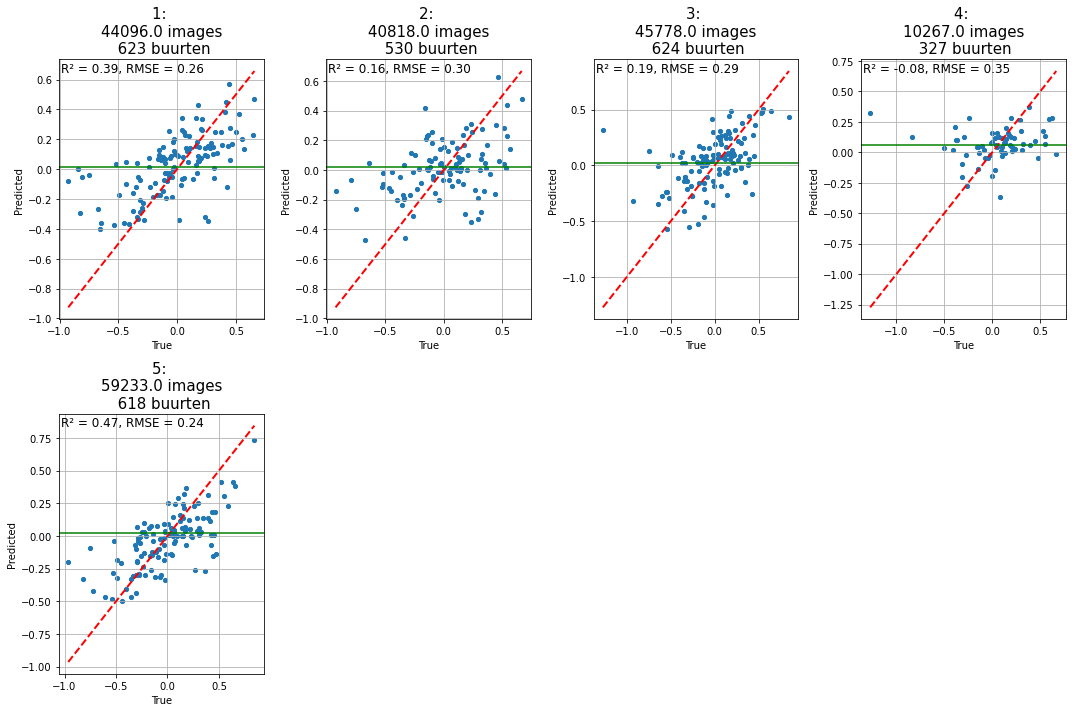

In [12]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(15, 10))
axs = axs.flatten()

results_per_cluster = {}

for i, cluster_num in enumerate(range(1, k + 1)):

    # Clone the best model for each cluster (avoid contamination between clusters)
    model = clone(best_model)

    emb_col = f'{cluster_num}_{statistic}'
    count_col = f'count_{cluster_num}'

    one_image_type = summary_df_with_ses[[JOIN_KEY, emb_col, count_col, var_to_predict]].copy()
    num_in_class = one_image_type[count_col].sum()

    # Drop buurten where this cluster has no images (embedding is NaN scalar)
    has_embedding = one_image_type[emb_col].apply(lambda x: not (isinstance(x, float) and np.isnan(x)))
    one_image_type = one_image_type[has_embedding].sort_values(JOIN_KEY).reset_index(drop=True)
    num_areas = len(one_image_type)
    print(f"Cluster {cluster_num}: {num_areas} buurten, {num_in_class:.0f} images")

    # Build feature matrix from embeddings
    X = np.stack(one_image_type[emb_col].values)
    y = one_image_type[var_to_predict].values

    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = evaluate_model(
        y_test, y_pred, cluster_num, num_in_class, num_areas,
        plot=False, plot_collectively=True, ax=axs[i])
    axs[i].axhline(y=one_image_type[var_to_predict].mean(), color='green', linestyle='-')

    results_per_cluster[cluster_num] = metrics

# Hide unused subplot axes
for j in range(i + 1, len(axs)):
    axs[j].axis("off")

fig.tight_layout()

### Results per cluster

In [13]:
pd.DataFrame(results_per_cluster)

,1,2,3,4,5
RMSE,0.259489,0.297529,0.288623,0.346124,0.237256
NRMSE,0.782781,0.917468,0.897567,1.037120,0.730629
MAE,0.193975,0.235707,0.209645,0.229135,0.180388
R2,0.387254,0.158252,0.194373,-0.075618,0.466181
Spearman_rank_corr,0.673800,0.386671,0.529084,0.241877,0.667972


### LaTeX table for paper
Export the per-cluster results as a LaTeX table, with metrics rounded for readability.

In [14]:
# Build a clean DataFrame for the LaTeX table
results_df = pd.DataFrame(results_per_cluster).T
results_df.index.name = "Cluster"

# Format for display: round RMSE/MAE, others to 3 decimal places
format_dict = {
    'RMSE': '{:.3f}',
    'NRMSE': '{:.3f}',
    'MAE': '{:.3f}',
    'R2': '{:.3f}',
    'Spearman_rank_corr': '{:.3f}',
}

# Rename columns for the paper
rename_map = {
    'RMSE': 'RMSE',
    'NRMSE': 'NRMSE',
    'MAE': 'MAE',
    'R2': r'$R^2$',
    'Spearman_rank_corr': r'Spearman $\rho$',
}
latex_df = results_df.rename(columns=rename_map)

# Generate LaTeX
latex_str = latex_df.to_latex(
    float_format="%.3f",
    formatters={
        'RMSE': lambda x: f'{x:.3f}',
        'NRMSE': lambda x: f'{x:.3f}',
        'MAE': lambda x: f'{x:.3f}',
        r'$R^2$': lambda x: f'{x:.3f}',
        r'Spearman $\rho$': lambda x: f'{x:.3f}',
    },
    caption="Per-cluster XGBoost model performance predicting SES-WOA score from street-view embeddings.",
    label="tab:per_cluster_results",
    column_format="lccccc",
    escape=False,
)

print(latex_str)

\begin{table}
\caption{Per-cluster XGBoost model performance predicting SES-WOA score from street-view embeddings.}
\label{tab:per_cluster_results}
\begin{tabular}{lccccc}
\toprule
 & RMSE & NRMSE & MAE & $R^2$ & Spearman $\rho$ \\
Cluster &  &  &  &  &  \\
\midrule
1 & 0.259 & 0.783 & 0.194 & 0.387 & 0.674 \\
2 & 0.298 & 0.917 & 0.236 & 0.158 & 0.387 \\
3 & 0.289 & 0.898 & 0.210 & 0.194 & 0.529 \\
4 & 0.346 & 1.037 & 0.229 & -0.076 & 0.242 \\
5 & 0.237 & 0.731 & 0.180 & 0.466 & 0.668 \\
\bottomrule
\end{tabular}
\end{table}

